# Workforce Attrition Causal Analysis
## Results & Statistical Testing

---

### Notebook Goals

This notebook uses the matched dataset produced in Notebook 2 to conduct 
a valid causal comparison of attrition rates between overtime and non-overtime 
employees. Because the matched groups are balanced across all observed 
covariates, differences in attrition rates can be interpreted as evidence 
of a causal relationship rather than a spurious correlation.

---

### Approach

1. Compare attrition rates between matched groups
2. Test for statistical significance using a chi-square test
3. Quantify the effect size using relative risk and risk difference
4. Assess robustness to unmeasured confounding via sensitivity analysis
5. Summarize findings in a stakeholder-ready format

## 1. Setup & Data Loading

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportion_confint

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)


matched_df = pd.read_pickle("../data/workforce_attrition_matched.pkl")
print(f"Shape: {matched_df.shape}")
matched_df.head()

Shape: (824, 39)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition_Binary,OverTime_Binary,Propensity_Score,JobInvolvement_x_JobLevel,JobInvolvement_x_MonthlyIncome,Propensity_Score_v2,Pair_ID
0,45,Yes,Travel_Rarely,1449,Sales,2,3,Marketing,1277,1,...,10,1,11,1,1,0.205285,5,18824,0.141909,0
1,38,No,Travel_Frequently,240,Research & Development,2,4,Life Sciences,803,1,...,7,4,12,0,1,0.174899,8,23920,0.174515,1
2,33,No,Travel_Frequently,515,Research & Development,1,2,Life Sciences,73,1,...,14,8,12,0,1,0.176016,9,40374,0.180523,2
3,33,Yes,Travel_Frequently,1076,Research & Development,3,3,Life Sciences,702,1,...,8,9,7,1,1,0.190716,3,10044,0.187417,3
4,32,No,Travel_Rarely,427,Research & Development,1,3,Medical,78,1,...,8,7,8,0,1,0.189869,6,18486,0.190061,4


## 2. Attrition Rate Comparison

With balanced groups established through propensity score matching, we 
now compare attrition rates between overtime and non-overtime employees. 
Unlike the raw comparison in Notebook 1, this comparison is made between 
groups that are similar across all observed covariates and can be 
interpreted as causal evidence.

  OverTime  Total  Attrition_Count  Attrition_Rate
0       No    412               40        9.708738
1      Yes    412              126       30.582524


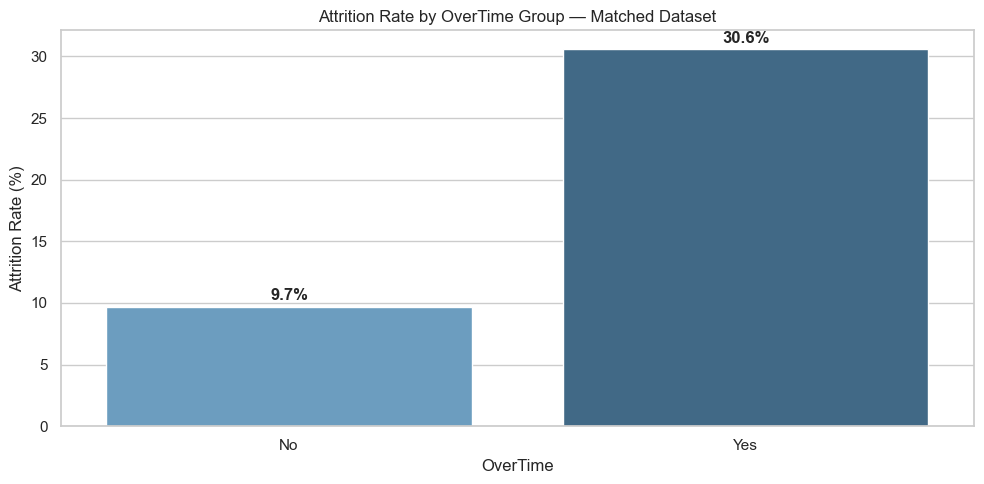

In [6]:
attrition_summary = matched_df.groupby("OverTime").agg(
    Total=("Attrition_Binary", "count"),
    Attrition_Count=("Attrition_Binary", "sum")
).reset_index()

attrition_summary["Attrition_Rate"] = (
    attrition_summary["Attrition_Count"] / attrition_summary["Total"] * 100
)

print(attrition_summary)

fig, ax = plt.subplots()
sns.barplot(
    x="OverTime",
    y="Attrition_Rate",
    data=attrition_summary,
    hue="OverTime",
    palette="Blues_d",
    legend=False,
    ax=ax
)
ax.set_title("Attrition Rate by OverTime Group — Matched Dataset")
ax.set_xlabel("OverTime")
ax.set_ylabel("Attrition Rate (%)")

for i, row in attrition_summary.iterrows():
    ax.text(i, row["Attrition_Rate"] + 0.5,
            f"{row['Attrition_Rate']:.1f}%", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("../outputs/10_matched_attrition_rate.png", dpi=150, bbox_inches="tight")
plt.show()

### Findings

In the matched dataset, employees who work overtime exhibit an attrition 
rate of 30.6% compared to 9.7% among matched non-overtime employees. 
This represents a difference of 20.9 percentage points between otherwise 
comparable groups.

Notably, this result is nearly identical to the raw unmatched comparison 
observed in Notebook 1 (30.5% vs 10.4%). The stability of the estimate 
across matched and unmatched comparisons suggests that the observed 
difference is not primarily driven by the confounding variables accounted 
for in the matching process, lending additional credibility to a causal 
interpretation.

We now test whether this difference is statistically significant.

## 3. Statistical Testing

We use a chi-square test of independence to assess whether the difference 
in attrition rates between matched groups is statistically significant. 
We also compute confidence intervals around each group's attrition rate 
to quantify the precision of our estimates.

In [7]:
overtime_attrition = matched_df[matched_df["OverTime"] == "Yes"]["Attrition_Binary"]
control_attrition = matched_df[matched_df["OverTime"] == "No"]["Attrition_Binary"]

contingency_table = pd.crosstab(
    matched_df["OverTime"],
    matched_df["Attrition"]
)
print("Contingency Table:")
print(contingency_table)

# Chi-square test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print(f"\nChi-Square Statistic: {chi2:.4f}")
print(f"P-Value: {p_value:.6f}")
print(f"Degrees of Freedom: {dof}")

# Confidence intervals
ci_overtime = proportion_confint(
    overtime_attrition.sum(), len(overtime_attrition), alpha=0.05, method="wilson"
)
ci_control = proportion_confint(
    control_attrition.sum(), len(control_attrition), alpha=0.05, method="wilson"
)

print(f"\n95% Confidence Interval — OverTime: ({ci_overtime[0]*100:.1f}%, {ci_overtime[1]*100:.1f}%)")
print(f"95% Confidence Interval — No OverTime: ({ci_control[0]*100:.1f}%, {ci_control[1]*100:.1f}%)")

Contingency Table:
Attrition   No  Yes
OverTime           
No         372   40
Yes        286  126

Chi-Square Statistic: 54.5043
P-Value: 0.000000
Degrees of Freedom: 1

95% Confidence Interval — OverTime: (26.3%, 35.2%)
95% Confidence Interval — No OverTime: (7.2%, 13.0%)


### Findings

The chi-square test confirms that the difference in attrition rates between 
matched groups is statistically significant (χ² = 54.50, p < 0.001). We 
reject the null hypothesis that overtime status and attrition are independent.

The 95% confidence intervals for each group do not overlap:

- Overtime employees: 26.3% to 35.2%
- Non-overtime employees: 7.2% to 13.0%

This confirms that the observed difference is not attributable to sampling 
variability. We now quantify the magnitude of this effect using relative 
risk and risk difference.

## 4. Effect Size

Statistical significance confirms that the observed difference is unlikely 
due to chance. Effect size measures quantify the magnitude and practical 
importance of that difference.

We compute two complementary measures:

- **Risk Difference (RD)** — the absolute difference in attrition rates 
between groups, expressed in percentage points
- **Relative Risk (RR)** — the ratio of attrition rates between groups, 
expressing how many times more likely overtime employees are to leave 
relative to their matched counterparts

Attrition Rate — OverTime: 30.6%
Attrition Rate — No OverTime: 9.7%

Risk Difference: 20.9 percentage points
Relative Risk: 3.15x


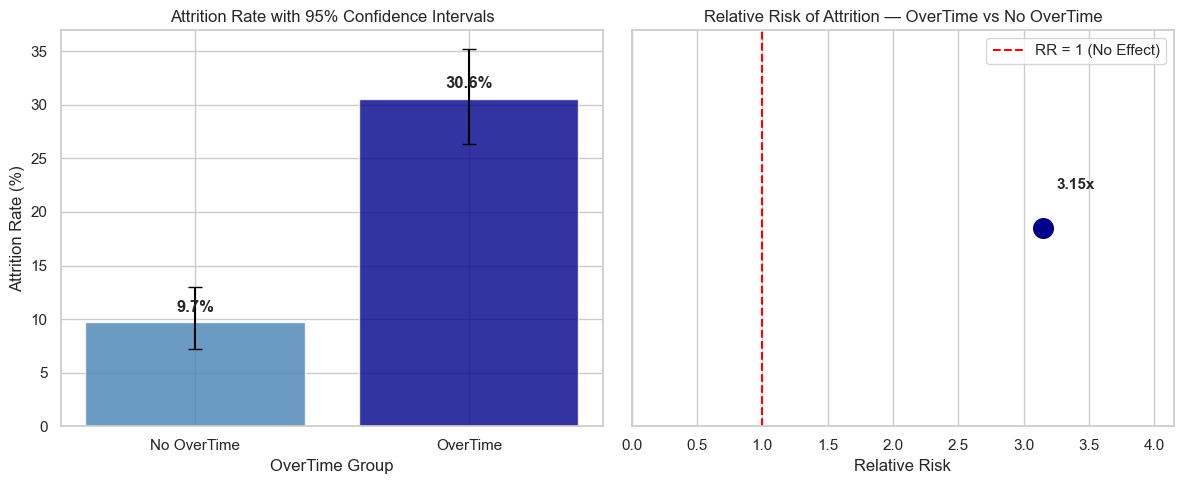

In [9]:
rate_overtime = overtime_attrition.mean()
rate_control = control_attrition.mean()

risk_difference = rate_overtime - rate_control
relative_risk = rate_overtime / rate_control

print(f"Attrition Rate — OverTime: {rate_overtime*100:.1f}%")
print(f"Attrition Rate — No OverTime: {rate_control*100:.1f}%")
print(f"\nRisk Difference: {risk_difference*100:.1f} percentage points")
print(f"Relative Risk: {relative_risk:.2f}x")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

categories = ["No OverTime", "OverTime"]
rates = [rate_control * 100, rate_overtime * 100]
errors = [
    [rate_control * 100 - ci_control[0] * 100, rate_overtime * 100 - ci_overtime[0] * 100],
    [ci_control[1] * 100 - rate_control * 100, ci_overtime[1] * 100 - rate_overtime * 100]
]

axes[0].bar(categories, rates, color=["steelblue", "darkblue"], alpha=0.8)
axes[0].errorbar(categories, rates, yerr=errors, fmt="none",
                 color="black", capsize=5, linewidth=1.5)
axes[0].set_title("Attrition Rate with 95% Confidence Intervals")
axes[0].set_ylabel("Attrition Rate (%)")
axes[0].set_xlabel("OverTime Group")
for i, r in enumerate(rates):
    axes[0].text(i, r + 1, f"{r:.1f}%", ha="center", fontweight="bold")

axes[1].scatter([relative_risk], [0], color="darkblue", s=200, zorder=5)
axes[1].axvline(x=1, color="red", linestyle="--", linewidth=1.5, label="RR = 1 (No Effect)")
axes[1].set_xlim(0, relative_risk + 1)
axes[1].set_ylim(-1, 1)
axes[1].set_yticks([])
axes[1].set_title("Relative Risk of Attrition — OverTime vs No OverTime")
axes[1].set_xlabel("Relative Risk")
axes[1].annotate(f"{relative_risk:.2f}x", xy=(relative_risk, 0),
                 xytext=(relative_risk + 0.1, 0.2), fontweight="bold", fontsize=11)
axes[1].legend()

plt.tight_layout()
plt.savefig("../outputs/11_effect_size.png", dpi=150, bbox_inches="tight")
plt.show()

### Findings

The effect size measures confirm a large and practically meaningful 
impact of overtime on employee attrition:

- **Risk Difference:** Overtime employees are 20.9 percentage points 
more likely to leave than their matched non-overtime counterparts
- **Relative Risk:** Overtime employees are 3.15 times more likely 
to leave than comparable employees who do not work overtime

Both measures consistently point to overtime as a strong driver of 
attrition. The magnitude of the effect — a tripling of attrition risk — 
represents a substantial organizational cost when accounting for 
recruitment, onboarding, and productivity loss associated with turnover.

We now assess the robustness of this finding to potential unmeasured 
confounding through sensitivity analysis.

## 5. Sensitivity Analysis

Propensity score matching controls for observed confounding variables. 
However, unmeasured variables — factors that influence both overtime 
assignment and attrition but were not captured in the dataset — could 
still bias our results.

Rosenbaum bounds sensitivity analysis addresses this by asking: how 
strong would an unmeasured confounder need to be to explain away the 
observed effect? The analysis introduces a sensitivity parameter Gamma (Γ) 
representing the odds ratio of treatment assignment due to an unmeasured 
confounder. At Γ = 1 there is no unmeasured confounding. As Γ increases 
we assess whether our conclusion remains statistically significant.

In [11]:
from scipy.stats import binom

def rosenbaum_bounds(treat, control, gammas):
    diff = treat.values - control.values
    
    # Use only discordant pairs
    discordant = diff[diff != 0]
    n = len(discordant)
    n_positive = (discordant > 0).sum()
    
    print(f"Total pairs: {len(diff)}")
    print(f"Discordant pairs: {n}")
    print(f"Pairs where treatment > control: {n_positive}")
    print(f"Pairs where control > treatment: {n - n_positive}\n")
    
    results = []
    for gamma in gammas:
        p_plus = gamma / (1 + gamma)
        p_minus = 1 / (1 + gamma)

        mean_plus = n * p_plus
        std_plus = np.sqrt(n * p_plus * (1 - p_plus))
        t_plus = (n_positive - mean_plus) / std_plus
        p_upper = 1 - stats.norm.cdf(t_plus)

        mean_minus = n * p_minus
        std_minus = np.sqrt(n * p_minus * (1 - p_minus))
        t_minus = (n_positive - mean_minus) / std_minus
        p_lower = 1 - stats.norm.cdf(t_minus)

        results.append({
            "Gamma": gamma,
            "P-Value Upper Bound": round(p_upper, 6),
            "P-Value Lower Bound": round(p_lower, 6)
        })
    return pd.DataFrame(results)

# Align pairs by Pair_ID
treatment_pairs = matched_df[matched_df["OverTime_Binary"] == 1].sort_values("Pair_ID")["Attrition_Binary"].reset_index(drop=True)
control_pairs = matched_df[matched_df["OverTime_Binary"] == 0].sort_values("Pair_ID")["Attrition_Binary"].reset_index(drop=True)

gammas = [1.0, 1.25, 1.5, 1.75, 2.0, 2.25, 2.5, 3.0]
sensitivity_df = rosenbaum_bounds(treatment_pairs, control_pairs, gammas)
print(sensitivity_df.to_string(index=False))

Total pairs: 412
Discordant pairs: 144
Pairs where treatment > control: 115
Pairs where control > treatment: 29

 Gamma  P-Value Upper Bound  P-Value Lower Bound
  1.00             0.000000                  0.0
  1.25             0.000000                  0.0
  1.50             0.000001                  0.0
  1.75             0.000026                  0.0
  2.00             0.000391                  0.0
  2.25             0.002856                  0.0
  2.50             0.012547                  0.0
  3.00             0.088966                  0.0


### Findings

The sensitivity analysis reveals that our conclusion is highly robust 
to unmeasured confounding.

Of 412 matched pairs, 144 were discordant — meaning treatment and control 
differed in attrition outcome. Of those, 115 favored the treatment group 
(overtime employees leaving) versus only 29 favoring the control group, 
a ratio consistent with our observed effect.

The upper bound p-values show how our conclusion holds as we increase Γ:

- At Γ = 1.0 (no unmeasured confounding): p < 0.001
- At Γ = 2.0: p = 0.000391 — still highly significant
- At Γ = 2.5: p = 0.013 — still significant at the 0.05 level
- At Γ = 3.0: p = 0.089 — significance begins to weaken

This means an unmeasured confounder would need to increase the odds of 
working overtime by more than 2.5 times to reduce our finding to 
borderline significance. Given that we have already controlled for age, 
income, job level, tenure, and other key covariates, an unmeasured 
confounder of that magnitude is unlikely. The causal effect of overtime 
on attrition is robust.

## 6. Stakeholder Summary

The following visual summarizes the key findings of this analysis in a 
format suitable for presentation to organizational leadership or HR 
decision makers.

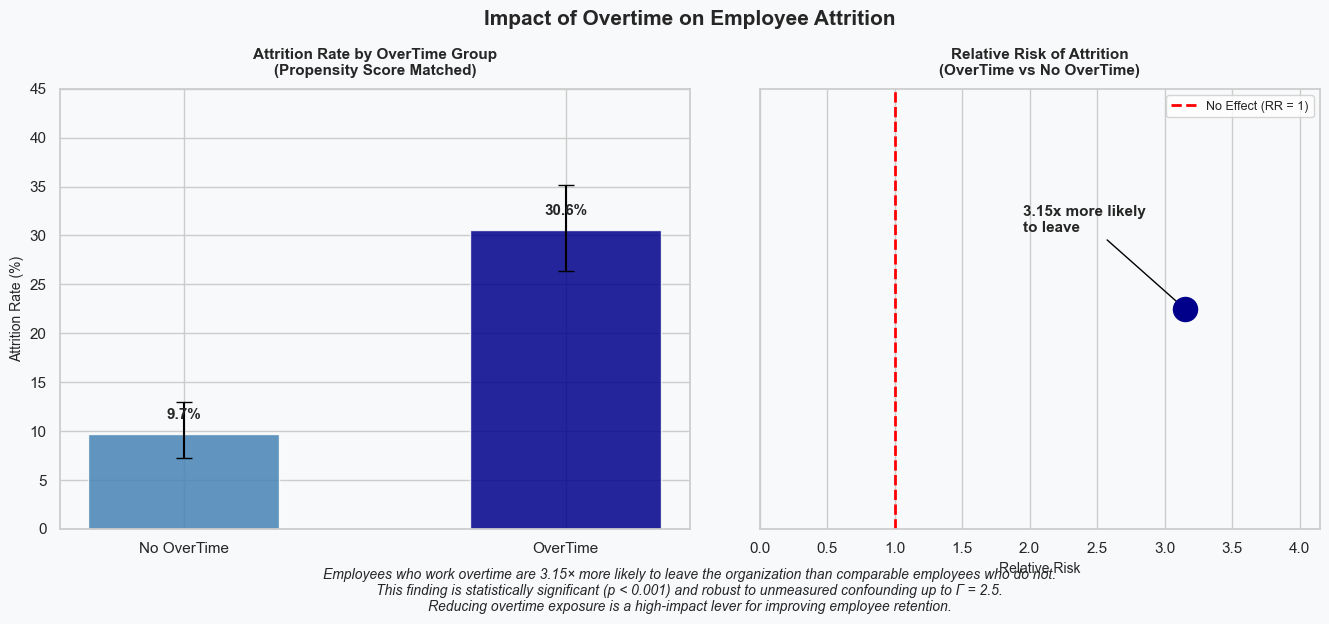

In [12]:
fig = plt.figure(figsize=(14, 8))
fig.patch.set_facecolor("#f8f9fa")

ax_main = fig.add_axes([0.05, 0.25, 0.45, 0.55])
ax_rr = fig.add_axes([0.55, 0.25, 0.4, 0.55])

categories = ["No OverTime", "OverTime"]
rates = [rate_control * 100, rate_overtime * 100]
errors = [
    [rate_control * 100 - ci_control[0] * 100, rate_overtime * 100 - ci_overtime[0] * 100],
    [ci_control[1] * 100 - rate_control * 100, ci_overtime[1] * 100 - rate_overtime * 100]
]

bars = ax_main.bar(categories, rates, color=["steelblue", "darkblue"], alpha=0.85, width=0.5)
ax_main.errorbar(categories, rates, yerr=errors, fmt="none",
                 color="black", capsize=6, linewidth=1.5)
ax_main.set_title("Attrition Rate by OverTime Group\n(Propensity Score Matched)",
                  fontsize=11, fontweight="bold", pad=10)
ax_main.set_ylabel("Attrition Rate (%)", fontsize=10)
ax_main.set_ylim(0, 45)
ax_main.set_facecolor("#f8f9fa")
for i, r in enumerate(rates):
    ax_main.text(i, r + 1.5, f"{r:.1f}%", ha="center", fontweight="bold", fontsize=11)

ax_rr.set_facecolor("#f8f9fa")
ax_rr.scatter([relative_risk], [0], color="darkblue", s=300, zorder=5)
ax_rr.axvline(x=1, color="red", linestyle="--", linewidth=2, label="No Effect (RR = 1)")
ax_rr.set_xlim(0, relative_risk + 1)
ax_rr.set_ylim(-1, 1)
ax_rr.set_yticks([])
ax_rr.set_title("Relative Risk of Attrition\n(OverTime vs No OverTime)",
                fontsize=11, fontweight="bold", pad=10)
ax_rr.set_xlabel("Relative Risk", fontsize=10)
ax_rr.annotate(f"{relative_risk:.2f}x more likely\nto leave",
               xy=(relative_risk, 0),
               xytext=(relative_risk - 1.2, 0.35),
               fontweight="bold", fontsize=11,
               arrowprops=dict(arrowstyle="->", color="black"))
ax_rr.legend(fontsize=9)

fig.text(0.5, 0.88, "Impact of Overtime on Employee Attrition",
         ha="center", fontsize=15, fontweight="bold")

fig.text(0.5, 0.15,
         u"Employees who work overtime are 3.15\u00d7 more likely to leave the organization than comparable employees who do not.\n"
         u"This finding is statistically significant (p < 0.001) and robust to unmeasured confounding up to \u0393 = 2.5.\n"
         u"Reducing overtime exposure is a high-impact lever for improving employee retention.",
         ha="center", fontsize=10, style="italic",
         wrap=True)

plt.savefig("../outputs/12_stakeholder_summary.png", dpi=150, bbox_inches="tight",
            facecolor="#f8f9fa")
plt.show()

## 7. Summary

This notebook used the propensity score matched dataset from Notebook 2 
to conduct a valid causal analysis of the effect of overtime on employee 
attrition.

**Attrition Rate Comparison**
In the matched dataset, overtime employees exhibit an attrition rate of 
30.6% compared to 9.7% among matched non-overtime employees — a difference 
of 20.9 percentage points between otherwise comparable groups. This result 
is nearly identical to the raw unmatched comparison, suggesting the effect 
is not driven by the confounders we controlled for.

**Statistical Significance**
The chi-square test confirms the difference is statistically significant 
(χ² = 54.50, p < 0.001). The 95% confidence intervals for the two groups 
do not overlap, confirming the result is not attributable to sampling 
variability.

**Effect Size**
Overtime employees are 3.15 times more likely to leave the organization 
than comparable non-overtime employees — a practically significant effect 
with substantial organizational cost implications.

**Sensitivity Analysis**
The finding remains statistically significant up to Γ = 2.5, meaning an 
unmeasured confounder would need to more than double the odds of overtime 
assignment to explain away the observed effect. Given the breadth of 
covariates already controlled for, this level of hidden confounding is 
unlikely.

**Recommendation**
Reducing employee overtime exposure is a high-impact lever for improving 
retention. Organizations should audit which roles and departments drive 
overtime demand, assess whether staffing levels are adequate, and monitor 
attrition risk among consistently overtime-exposed employees.